# Task 1

## 1.1 Data Import and Cleaning

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Region summary_ New South Wales STE 1.csv")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")
df = df.drop_duplicates()

text_cols = ["measure_code", "parent_description", "description"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

year_cols = [col for col in df.columns if col.isdigit()]

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["description"].notna()]
df = df[df["description"].str.lower() != "nan"]

cleaned_wide = df.copy()

cleaned_tidy = cleaned_wide.melt(
    id_vars=["measure_code", "parent_description", "description"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

cleaned_tidy["year"] = cleaned_tidy["year"].astype(int)
cleaned_tidy = cleaned_tidy.dropna(subset=["value"])
cleaned_tidy = cleaned_tidy.sort_values(
    by=["description", "year"]
).reset_index(drop=True)

cleaned_wide.to_csv("nsw_region_summary_cleaned_wide.csv", index=False)
cleaned_tidy.to_csv("nsw_region_summary_cleaned_tidy.csv", index=False)

## 1.2 Individual Statistics

In [2]:
df = pd.read_csv("nsw_region_summary_cleaned_wide.csv")

measure_code_map = {
    "total_resident_population": "ERP_P_20",
    "working_age_population_15_64": "ERP_18",
    "resident_male_population": "ERP_M_20",
    "resident_female_population": "ERP_F_20",
    
    "pop_0_4_total": "ERP_P_2",
    "pop_5_9_total": "ERP_P_3",
    "pop_10_14_total": "ERP_P_4",
    
    "pop_0_4_male": "ERP_M_2",
    "pop_5_9_male": "ERP_M_3",
    "pop_10_14_male": "ERP_M_4",
    
    "pop_0_4_female": "ERP_F_2",
    "pop_5_9_female": "ERP_F_3",
    "pop_10_14_female": "ERP_F_4",
    
    "pop_65_69": "ERP_P_15",
    "pop_70_74": "ERP_P_16",
    "pop_75_79": "ERP_P_17",
    "pop_80_84": "ERP_P_18",
    "pop_85_plus": "ERP_P_19",
    
    "overseas_born_total": "TOTMIG_4",
    "overseas_15_19": "AGEMIG_5",
    "overseas_20_24": "AGEMIG_6",
    "overseas_25_29": "AGEMIG_7",
    "overseas_30_34": "AGEMIG_8",
    "overseas_35_39": "AGEMIG_9",
    "overseas_40_44": "AGEMIG_10",
    "overseas_45_49": "AGEMIG_11",
    "overseas_50_54": "AGEMIG_12",
    "overseas_55_59": "AGEMIG_13",
    "overseas_60_64": "AGEMIG_14",
}

df_base = df[df['measure_code'].isin(measure_code_map.values())].copy()
df_base['metric_name'] = df_base['measure_code'].map({v: k for k, v in measure_code_map.items()})
df_base = df_base.drop_duplicates(subset=['metric_name'])
df_base = df_base.set_index('metric_name')[year_cols].T.astype(float)

df_base['pop_0_14_total'] = df_base[['pop_0_4_total', 'pop_5_9_total', 'pop_10_14_total']].sum(axis=1)
df_base['pop_0_14_male_total'] = df_base[['pop_0_4_male', 'pop_5_9_male', 'pop_10_14_male']].sum(axis=1)
df_base['pop_0_14_female_total'] = df_base[['pop_0_4_female', 'pop_5_9_female', 'pop_10_14_female']].sum(axis=1)
df_base['pop_65_plus_total'] = df_base[['pop_65_69', 'pop_70_74', 'pop_75_79', 'pop_80_84', 'pop_85_plus']].sum(axis=1)
df_base["overseas_wa_15_64"] = df_base[["overseas_15_19", "overseas_20_24", "overseas_25_29", "overseas_30_34","overseas_35_39",
                                       "overseas_40_44", "overseas_45_49", "overseas_50_54","overseas_55_59", "overseas_60_64"]].sum(axis=1)

df_base["local_born_total"] = (df_base["total_resident_population"] - df_base["overseas_born_total"])
df_base["local_wa_15_64"] = (df_base["working_age_population_15_64"] - df_base["overseas_wa_15_64"])
df_base['child_sex_ratio(male/female)'] = (df_base['pop_0_14_male_total'] / df_base['pop_0_14_female_total'])
df_base['total_sex_ratio(male/female)'] = ( df_base['resident_male_population'] / df_base['resident_female_population'])
df_base["overseas_working_age_share(%)"] = np.where(
    df_base["overseas_born_total"].isna() | (df_base["overseas_born_total"] == 0),
    np.nan,
    df_base["overseas_wa_15_64"] / df_base["overseas_born_total"] * 100,
)
df_base["local_working_age_share(%)"] = np.where(
    df_base["local_born_total"].isna() | (df_base["local_born_total"] <= 0),
    np.nan,
    df_base["local_wa_15_64"] / df_base["local_born_total"] * 100,
)

result = pd.DataFrame(index=df_base.index)
result.index.name = 'year'

# 1
result['youth-population sex ratio differential'] = (
    df_base['child_sex_ratio(male/female)'] - df_base['total_sex_ratio(male/female)'] ).round(4)

# 2
result['child_dependency_ratio(%)'] = np.where(
    df_base['working_age_population_15_64'] == 0,
    np.nan,
    (df_base['pop_0_14_total'] / df_base['working_age_population_15_64']) * 100
).round(2)

# 3
result['old_age_dependency_ratio(%)'] = np.where(
    df_base['working_age_population_15_64'] == 0,
    np.nan,
    (df_base['pop_65_plus_total'] / df_base['working_age_population_15_64']) * 100
).round(2)

# 4
df_base['elderly_population_share'] = np.where(df_base['total_resident_population'] == 0, np.nan, df_base['pop_65_plus_total'] / df_base['total_resident_population'])
df_base['child_population_share'] = np.where(df_base['total_resident_population'] == 0, np.nan, df_base['pop_0_14_total'] / df_base['total_resident_population'])
result['population_aging_index'] = np.where(
    df_base['child_population_share'] == 0,
    np.nan,
    df_base['elderly_population_share'] / df_base['child_population_share']
).round(4)

# 5
result["Overseas–local born working-age share gap"] = (
    df_base["overseas_working_age_share(%)"] - df_base["local_working_age_share(%)"]
).round(2)

result_clean = result.dropna(how='all').replace(0, np.nan).dropna(how='all')
result_clean = result_clean.sort_index()

print(result_clean.to_string())

      youth-population sex ratio differential  child_dependency_ratio(%)  old_age_dependency_ratio(%)  population_aging_index  Overseas–local born working-age share gap
year                                                                                                                                                                    
2019                                   0.0718                      28.46                        25.08                  0.8812                                        NaN
2020                                   0.0727                      28.46                        25.86                  0.9087                                        NaN
2021                                   0.0733                      28.67                        26.75                  0.9330                                      13.41
2022                                   0.0724                      28.49                        27.15                  0.9529                              

## 1.3 Key Findings

1. Youth–Total population sex ratio differential

This measure is the child sex ratio (males per female, ages 0–14) minus the total population sex ratio.

From 2019 to 2024, it stayed around 0.071–0.073. Children are more male-heavy than the whole population. Over time, the gap is fairly stable. This may slowly push the total sex ratio upward in future years. Consider other influences (such as immigration). It is only an indicator of gender imbalance among young people, not robust evidence for forecasting future population sex structure.

2. Child dependency ratio

This is the share of children (0–14) compared to the working-age population (15–64), in percent.

It fell from 28.46% in 2019 to 27.12% in 2024. Fewer children per 100 working-age people means less pressure from child-rearing. This might also imply a low-fertility trend in NSW.

3. Old-age dependency ratio

This is the share of people aged 65+ compared to the working-age population (15–64), in percent.

It rose from 25.08% in 2019 to 27.32% in 2024. More elderly people per 100 working-age people means more pressure for care and services. This may indicate population ageing.

4. Population aging index

This is the elderly population share divided by the child population share. If the value is above 1, the elderly group is larger than the child group (as a share of total population).

The index rose from 0.8812 in 2019 to 1.0074 in 2024. In 2024 it passed 1 for the first time in this period. The elderly share is now slightly larger than the child share.

Together, findings 2–4 point to an ageing trend: child dependency fell slightly, old-age dependency rose, and ageing accelerated.

5. Overseas–local born working-age share gap (Census 2021)

This is the difference (in percentage points) between:

the share of overseas-born people aged 15–64, and
the share of Australia-born people aged 15–64.

Overseas-born residents are more concentrated in working ages (15–64) than Australia-born residents, by about 13.41 percentage points. This may support labour supply from migrants in a broad sense, but it does not measure job quality, wages, or access to services.

Note: Overseas-born age data come from the Census and are available for 2021 only, not for 2019–2024. Overseas-born population is used as a proxy for the migrant stock, including long-term residents and Australian citizens born abroad, not only recent arrivals.


# Task 2

## 2.1 Shape file import

In [113]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import json
import os
from sqlalchemy import create_engine, text
import psycopg2
import geoalchemy2

sa4_gdf = gpd.read_file("SA4_2021_AUST_SHP_GDA2020/SA4_2021_AUST_GDA2020.shp")

sa2_gdf = gpd.read_file("SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp")

selected_sa4 = sa4_gdf[sa4_gdf["SA4_NAME21"] == "Sydney - Inner West"] # "Sydney - City and Inner South" "Sydney - South West"

sa2_in_selected_sa4 = sa2_gdf[sa2_gdf.within(selected_sa4.geometry.iloc[0])]

#selected_greater_sydney = sa2_gdf[sa2_gdf["GCC_NAME21"] == "Greater Sydney"]

#print(selected_greater_sydney["SA4_NAME21"].unique())

#print(sa2_in_selected_sa4)

## 2.2 Search POIs
Iterate through all SA2s in the selected SA4 to collect POIs and build a dataframe that contains all attributes and geometry information.

In [114]:
def nearbyPOI(xmin, ymin, xmax, ymax):
    base_url = "https://maps.six.nsw.gov.au/arcgis/rest/services/public/NSW_POI/MapServer/0/query"
    params = {
        "geometry": f'{{"xmin":{xmin},"ymin":{ymin},"xmax":{xmax},"ymax":{ymax},"spatialReference":{{"wkid":4326}}}}',
        "outFields": "*",
        "returnGeometry": "true",
        "f": "json"
    }
    r = requests.get(base_url, params=params)
    return r.json().get("features", [])

def collect_poi_for_sa2(sa2_subset):
    all_poi = []
    sa2_wgs84 = sa2_subset.to_crs("EPSG:4326")
    for idx, row in sa2_wgs84.iterrows():
        sa2_code = row["SA2_CODE21"]
        sa2_name = row["SA2_NAME21"]
        xmin, ymin, xmax, ymax = row.geometry.bounds
        sa2_geom = row.geometry
        pois = nearbyPOI(xmin, ymin, xmax, ymax)
        for p in pois:
            lon = p["geometry"]["x"]
            lat = p["geometry"]["y"]
            point = gpd.points_from_xy([lon], [lat])[0]
            if sa2_geom.covers(point):
                p["attributes"]["SA2_CODE21"] = sa2_code
                p["attributes"]["SA2_NAME21"] = sa2_name
                all_poi.append(p)
    rows = [{**p["attributes"], **p["geometry"]} for p in all_poi]
    return pd.DataFrame(rows)

poi_df = collect_poi_for_sa2(sa2_in_selected_sa4)
#print(poi_df)

## 2.3 database operation
Connect to postgres with postGis extension and insert/read GeoDataFrame with database using python

Note: needs to create Credentials.json by below chunk before connection


In [115]:
if not os.path.exists("Credentials.json"):
    config_data = {
        "host": "localhost",
        "user": "postgres",
        "password": "password", # your own password
        "port": 5432
    }

    with open("Credentials.json", "w", encoding="utf-8") as f:
        json.dump(config_data, f, indent=4)
        

In [116]:
credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath, 'r') as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db, conn
    
def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

db, conn = pgconnect(credentials)

with conn.begin():
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS postgis;"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS pois;"))
    conn.execute(text("DROP TABLE IF EXISTS pois.poi;")) 

poi_gdf = gpd.GeoDataFrame(poi_df, geometry= gpd.points_from_xy(poi_df['x'], poi_df['y']), crs="EPSG:4326")

#print(poi_gdf)

poi_gdf.to_postgis("poi", conn, schema="pois", if_exists="replace")

display(query(conn, "SELECT * FROM pois.poi LIMIT 10;"))

conn.close()

db.dispose()


Connected successfully.


,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,poialtlabel,poisourcefeatureoid,accesscontrol,...,centroidid,shapeuuid,changetype,processstate,urbanity,SA2_CODE21,SA2_NAME21,x,y,geometry
0,849,500175264,1,Place Of Worship,NaN,CATHOLIC CHURCH,DERIVED,CATHOLIC,19,1,...,None,ecdfa4df-749c-3b3a-9c10-4c1182d018d1,I,None,U,120011383,Concord - Mortlake - Cabarita,151.109531,-33.860946,0101000020E61000008A5A164781E36240C234E47B33EE...
1,852,500175364,1,Place Of Worship,NaN,SEVENTH DAY ADVENTIST CHURCH,DERIVED,SEVENTH DAY ADVENTIST,19,1,...,None,4e17af84-e621-3e33-9c2e-0c94d698f337,M,None,U,120011383,Concord - Mortlake - Cabarita,151.100483,-33.861704,0101000020E6100000E4F9DD2837E3624025F5FA504CEE...
2,1120,500189404,3,Golf Course,CONCORD GOLF COURSE,CONCORD GOLF COURSE,NAMED,NaN,54,1,...,None,309c521f-dbba-3555-8937-b63f643f57e9,I,None,U,120011383,Concord - Mortlake - Cabarita,151.097332,-33.850397,0101000020E61000008D3997581DE36240DF45BCCBD9EC...
3,1121,500189426,3,Park,PRINCE EDWARD PARK,PRINCE EDWARD PARK,NAMED,NaN,61,1,...,None,d6f98b1f-5ea3-3c86-9443-180b60ef1bec,I,None,U,120011383,Concord - Mortlake - Cabarita,151.119009,-33.852815,0101000020E6100000E42DF0EACEE362408B38CC0829ED...
4,1122,500189437,3,Golf Course,MASSEY PARK GOLF COURSE,MASSEY PARK GOLF COURSE,NAMED,NaN,54,1,...,None,6cb197f3-fb80-3f16-afc6-b8011ce8a7fe,I,None,U,120011383,Concord - Mortlake - Cabarita,151.111647,-33.853167,0101000020E61000000A4EF29C92E36240E584A89734ED...
5,1125,500189470,3,Park,STEWART RESERVE,STEWART RESERVE,NAMED,NaN,61,1,...,None,519c8dcb-5237-3bec-8686-7d7faabaea09,I,None,U,120011383,Concord - Mortlake - Cabarita,151.106816,-33.857835,0101000020E6100000110091086BE362401D5CE188CDED...
6,1128,500189527,3,Park,HENLEY PARK,HENLEY PARK,NAMED,NaN,61,1,...,None,0b15b8f9-07b8-3efb-beb5-648fc60bce33,I,None,U,120011383,Concord - Mortlake - Cabarita,151.098725,-33.859951,0101000020E6100000656184C028E36240AC1B8FDF12EE...
7,1129,500189538,3,Park,CENTRAL PARK,CENTRAL PARK,NAMED,NaN,61,1,...,None,5dd22b58-b4ee-399b-aaf0-4c7ac21bf67a,I,None,U,120011383,Concord - Mortlake - Cabarita,151.096315,-33.856830,0101000020E61000009666520215E362406C731C9BACED...
8,1134,500189627,3,Park,BAYVIEW PARK,BAYVIEW PARK,NAMED,NaN,61,1,...,None,a0f63a4c-e628-39d2-8939-f794a270c50c,I,None,U,120011383,Concord - Mortlake - Cabarita,151.121292,-33.857895,0101000020E610000063682B9FE1E36240E0073B7DCFED...
9,1146,500189971,3,Park,WANGAL RESERVE,WANGAL RESERVE,NAMED,NaN,61,1,...,None,3e37d08b-634a-3a22-86eb-ae4ae466b27e,M,None,U,120011383,Concord - Mortlake - Cabarita,151.104409,-33.835145,0101000020E6100000472D365157E362402FDED908E6EA...


# Task 3

## 3.1 basic Z-score and Sigmoid

In [117]:
import pandas as pd
import numpy as np

poi_count = poi_df.groupby("SA2_NAME21").size().reset_index()
poi_count.columns = ["sa2_name", "poi_num"]

mean_poi = poi_count["poi_num"].mean()
std_poi = poi_count["poi_num"].std(ddof=0)
poi_count["z_poi"] = (poi_count["poi_num"] - mean_poi) / std_poi


poi_count["score"] = 1 / (1 + np.exp(-poi_count["z_poi"]))

poi_count = poi_count.sort_values(by="score", ascending=False)
print(poi_count.to_string())
print(len(poi_count))


                            sa2_name  poi_num     z_poi     score
10            Drummoyne - Rodd Point      267  2.671865  0.935346
16               Lilyfield - Rozelle      235  2.185808  0.898968
15                        Leichhardt      192  1.532670  0.822397
3                            Balmain      152  0.925099  0.716080
13          Haberfield - Summer Hill      121  0.454232  0.611645
6      Concord - Mortlake - Cabarita      113  0.332717  0.582420
12            Five Dock - Abbotsford       89 -0.031825  0.492044
4                      Burwood (NSW)       87 -0.062204  0.484454
9             Croydon Park - Enfield       79 -0.183718  0.454199
14                          Homebush       63 -0.426746  0.394904
0                    Annandale (NSW)       58 -0.502693  0.376908
2                   Ashfield - South       58 -0.502693  0.376908
7   Concord West - North Strathfield       57 -0.517882  0.373348
19                Strathfield - West       57 -0.517882  0.373348
8         

## 3.2 Scoring with population filter

No SA2s in this SA4 have a population below 100.

In [118]:
pop = pd.read_csv(
    "ABS_ERP_2001_2023_SA2_1163063899690146738.csv",
    usecols=[
        "Statistical Areas Level 2 2021 name",
        "2021 Estimated resident population (no.)",
    ],
)
pop.columns = ["SA2_NAME21", "population"]
pop["SA2_NAME21"] = pop["SA2_NAME21"].astype(str)

poi_count_withpop = poi_df.groupby("SA2_NAME21").size().reset_index(name="poi_num")
df = poi_count_withpop.merge(pop, on="SA2_NAME21")
df = df[df["population"] >= 100]

mean_poi = df["poi_num"].mean()
std_poi = df["poi_num"].std(ddof=0)
df["z_poi"] = (df["poi_num"] - mean_poi) / std_poi
df["score"] = 1 / (1 + np.exp(-df["z_poi"]))

poi_count_withpop = df.sort_values("score", ascending=False)
print(poi_count_withpop.to_string())
print(len(poi_count_withpop))

                          SA2_NAME21  poi_num  population     z_poi     score
10            Drummoyne - Rodd Point      267     18409.0  2.671865  0.935346
16               Lilyfield - Rozelle      235     13870.0  2.185808  0.898968
15                        Leichhardt      192     17630.0  1.532670  0.822397
3                            Balmain      152     15634.0  0.925099  0.716080
13          Haberfield - Summer Hill      121     13560.0  0.454232  0.611645
6      Concord - Mortlake - Cabarita      113     23214.0  0.332717  0.582420
12            Five Dock - Abbotsford       89     21003.0 -0.031825  0.492044
4                      Burwood (NSW)       87     16071.0 -0.062204  0.484454
9             Croydon Park - Enfield       79     17468.0 -0.183718  0.454199
14                          Homebush       63     21056.0 -0.426746  0.394904
0                    Annandale (NSW)       58      9519.0 -0.502693  0.376908
2                   Ashfield - South       58     12283.0 -0.502

## 3.3 Scoring with median rather than mean

Within this SA4, some SA2s have very high POI totals compared with others. Using the mean and standard deviation allows these extremes to strongly affect the scale of all z-scores. We therefore replace the mean with the median and the standard deviation with the median absolute deviation (MAD) to reduce this effect.

In [119]:
MIN_POP = 100

def score_sa2_in_sa4(poi_df_sa4, sa4_name):
    poi_count = poi_df_sa4.groupby("SA2_NAME21").size().reset_index(name="poi_num")
    df = poi_count.merge(pop, on="SA2_NAME21", how="left")
    df = df[df["population"] >= MIN_POP].copy()
    x = df["poi_num"]
    med = x.median()
    mad = (x - med).abs().median()
    df["z_poi"] = (x - med) / mad if mad > 0 else 0.0
    df["score"] = 1 / (1 + np.exp(-df["z_poi"]))
    df["SA4_NAME21"] = sa4_name
    return df.sort_values("score", ascending=False)

poi_count_with_pop_and_median = score_sa2_in_sa4(poi_df, "Sydney - Inner West")
print(poi_count_with_pop_and_median.to_string())
print(len(poi_count_with_pop_and_median))

                          SA2_NAME21  poi_num  population     z_poi     score           SA4_NAME21
10            Drummoyne - Rodd Point      267     18409.0  8.038462  0.999677  Sydney - Inner West
16               Lilyfield - Rozelle      235     13870.0  6.807692  0.998896  Sydney - Inner West
15                        Leichhardt      192     17630.0  5.153846  0.994256  Sydney - Inner West
3                            Balmain      152     15634.0  3.615385  0.973798  Sydney - Inner West
13          Haberfield - Summer Hill      121     13560.0  2.423077  0.918570  Sydney - Inner West
6      Concord - Mortlake - Cabarita      113     23214.0  2.115385  0.892390  Sydney - Inner West
12            Five Dock - Abbotsford       89     21003.0  1.192308  0.767154  Sydney - Inner West
4                      Burwood (NSW)       87     16071.0  1.115385  0.753132  Sydney - Inner West
9             Croydon Park - Enfield       79     17468.0  0.807692  0.691618  Sydney - Inner West
14        

# Task 4

## 4.1 Intra distribution of score

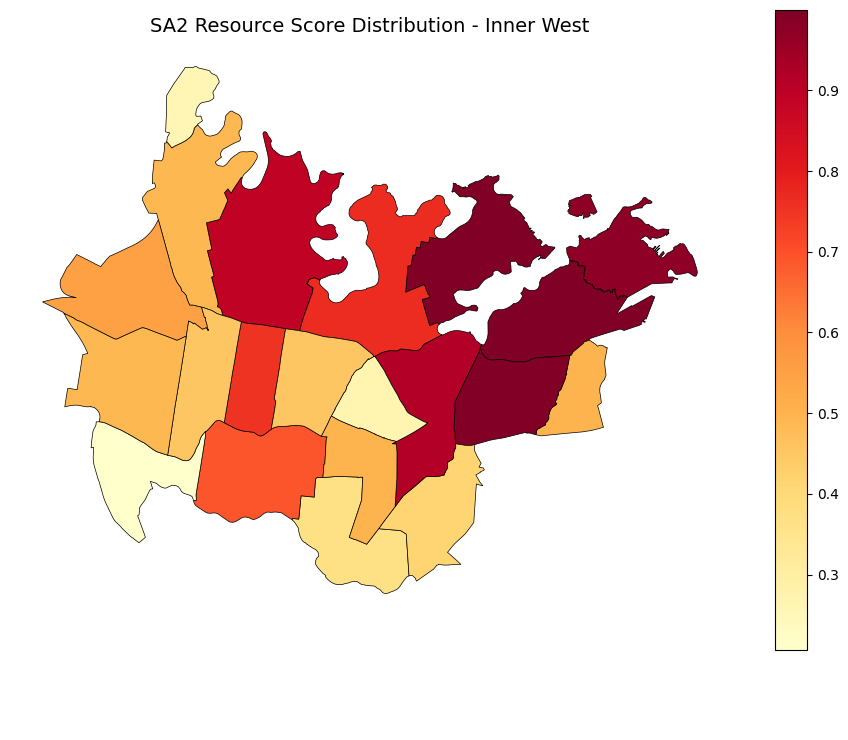

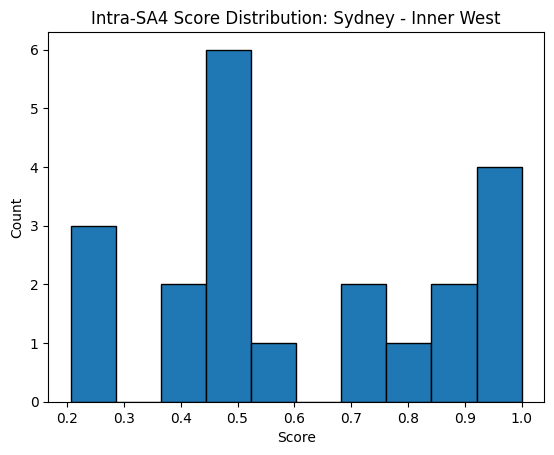

In [120]:
import matplotlib.pyplot as plt

def plot_sa2_score_distribution(sa2_in_selected_sa4,score_sa2_in_sa4, plot_name, bottom_text):
    
    sa2s = sa2_in_selected_sa4.merge(
        score_sa2_in_sa4,
        left_on="SA2_NAME21",
        right_on="SA2_NAME21",
        how="left"
        )
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    sa2s.plot(
        column="score",
        cmap="YlOrRd",
        linewidth=0.5,
        ax=ax,
        edgecolor="black",
        legend=True
        )
    ax.set_title(plot_name, fontsize=14)
    ax.axis("off")
    
    fig.text(
    0.5, 0.02,
    bottom_text,
    ha="center",
    va="bottom",
    fontsize=10,
    style="italic",
    )
    fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.12)
    plt.show()
    
plot_sa2_score_distribution(sa2_in_selected_sa4, poi_count_with_pop_and_median
                            , "SA2 Resource Score Distribution - Inner West", " ")

plt.hist(poi_count_with_pop_and_median["score"].dropna(), bins=10, edgecolor="black")
plt.title("Intra-SA4 Score Distribution: Sydney - Inner West")
plt.xlabel("Score"); plt.ylabel("Count")
plt.show()


## 4.2 Inter distribution of score

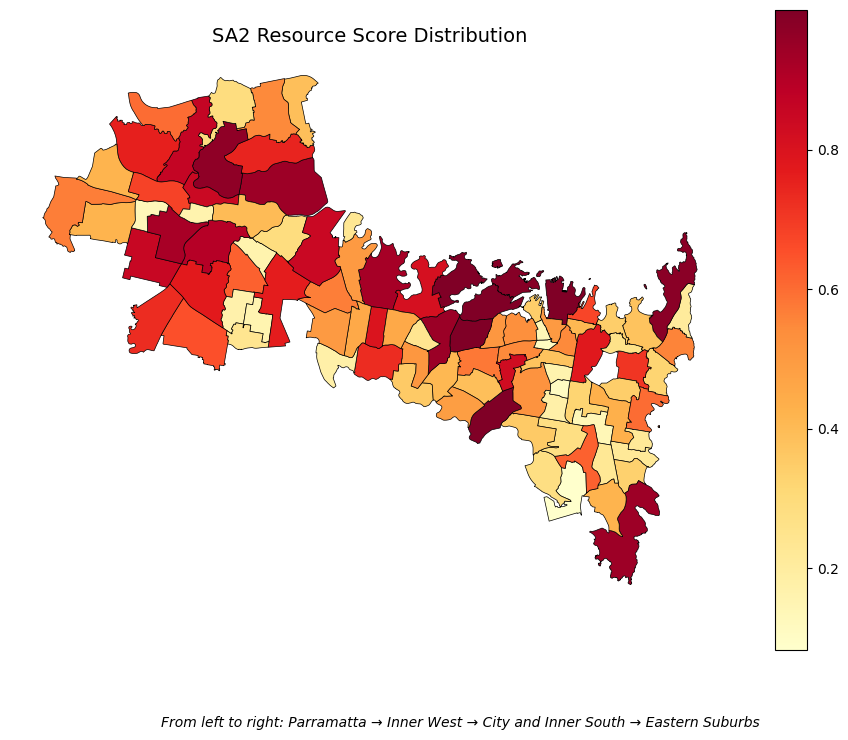

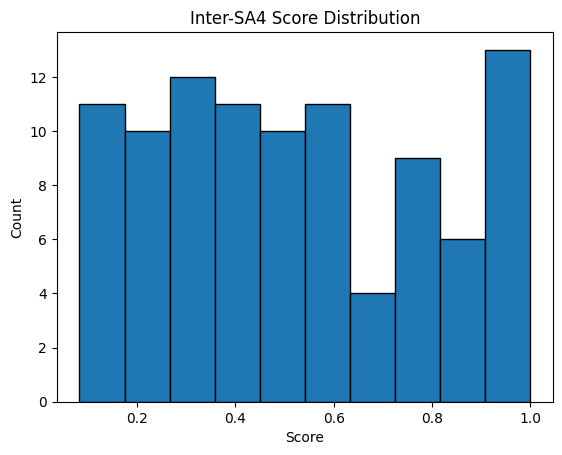

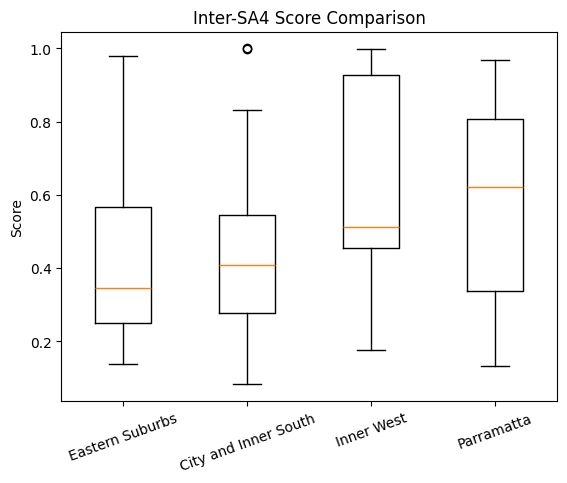

In [121]:
SA4_LIST = [
    "Sydney - Eastern Suburbs",
    "Sydney - City and Inner South",
    "Sydney - Inner West",
    "Sydney - Parramatta",
]

sa2s = []
pois = []

for sa4_name in SA4_LIST:
    selected_sa4 = sa4_gdf[sa4_gdf["SA4_NAME21"] == sa4_name]
    sa2_in_selected_sa4 = sa2_gdf[sa2_gdf.within(selected_sa4.geometry.iloc[0])].copy()
    poi = collect_poi_for_sa2(sa2_in_selected_sa4)
    sa2s.append(sa2_in_selected_sa4)
    pois.append(poi)

sa2_all = pd.concat(sa2s, ignore_index=True)
poi_all = pd.concat(pois, ignore_index=True) 
score_all = score_sa2_in_sa4(poi_all, "All four SA4s")
score_all = score_all.drop(columns=["SA4_NAME21"], errors="ignore").merge(
    sa2_all[["SA2_NAME21", "SA4_NAME21"]].drop_duplicates(),
    on="SA2_NAME21",
    how="left",
)
    
bottom_text = "From left to right: Parramatta → Inner West → City and Inner South → Eastern Suburbs"
    
plot_sa2_score_distribution(sa2_all, score_all, "SA2 Resource Score Distribution", bottom_text)

plt.hist(score_all["score"].dropna(), bins=10, edgecolor="black")
plt.title("Inter-SA4 Score Distribution")
plt.xlabel("Score"); plt.ylabel("Count")
plt.show()

data = [score_all.loc[score_all["SA4_NAME21"]==s, "score"].dropna() for s in SA4_LIST]
plt.boxplot(data, tick_labels=[s.replace("Sydney - ", "") for s in SA4_LIST])
plt.ylabel("Score"); plt.title("Inter-SA4 Score Comparison")
plt.xticks(rotation=20); plt.show()




In [122]:
print(score_all.groupby("SA4_NAME21")["score"].median())
print(score_all.groupby("SA4_NAME21")["score"].mean())
print(score_all.groupby("SA4_NAME21")["poi_num"].max())

SA4_NAME21
Sydney - City and Inner South    0.410080
Sydney - Eastern Suburbs         0.346069
Sydney - Inner West              0.511362
Sydney - Parramatta              0.622459
Name: score, dtype: float64
SA4_NAME21
Sydney - City and Inner South    0.442299
Sydney - Eastern Suburbs         0.437961
Sydney - Inner West              0.624656
Sydney - Parramatta              0.574992
Name: score, dtype: float64
SA4_NAME21
Sydney - City and Inner South    354
Sydney - Eastern Suburbs         141
Sydney - Inner West              267
Sydney - Parramatta              132
Name: poi_num, dtype: int64


Within Inner West (SA4), scores are highly uneven. Several SA2s in the north-east part of the SA4 reach the upper end of the scale , while many SA2s in the west and south-west fall in the 0.2–0.5 range. This confirms that POI-based resourcing is not uniform inside the Inner West.

Across Parramatta, Inner West, City and Inner South, and Eastern Suburbs, the four-SA4 map shows that high scores are concentrated near the Sydney Harbour and Parramatta River, the north of these four regions. And from the box plot, Parramatta has the highest median, Inner West next, City and Inner South, and Eastern Suburbs the lowest median. All four SA4s span a wide range (roughly 0.1–1.0). So there are both variations of scoring inside and across SA4 regions.

In conclusion, scores are uneven in space. Inner West is polarised east–west, and the four-SA4 view and boxplot shows Sydney Harbour and Parramatta River clustering plus big within-region spreads.This spatial distribution highlights a waterfront concentration, which might be driven by historical development along river transport. The scoring uses median and median absolute deviation instead of mean and standard deviation to counter effects of outliers. And it is also filtering out SA2s with populations under 100.